In [1]:
import pandas as pd
import numpy as np
import joblib

# Load saved models
model1 = joblib.load("../models/iri_prediction_model.pkl")
model2 = joblib.load("../models/fwd_health_model.pkl")
le_target = joblib.load("../models/fwd_label_encoder.pkl")

print("Models loaded successfully!")

# Load Data
iri = pd.read_excel("../data/MON_HSS_PROFILE_SECTION.xlsx")
trf1 = pd.read_excel("../data/TRF_TREND_1.xlsx")
trf2 = pd.read_excel("../data/TRF_TREND.xlsx")
fwd = pd.read_excel("../data/MON_DEFL_DROP_DATA.xlsx")
exp = pd.read_excel("../data/EXPERIMENT_SECTION.xlsx")

print("All data loaded!")
print("IRI shape:", iri.shape)
print("FWD shape:", fwd.shape)

Models loaded successfully!
All data loaded!
IRI shape: (65534, 11)
FWD shape: (65534, 25)


In [2]:
# --- MODEL 1 DATA PREP ---
iri['VISIT_DATE'] = pd.to_datetime(iri['VISIT_DATE'])
iri['YEAR'] = iri['VISIT_DATE'].dt.year
iri = iri.drop(columns=['IRI_CENTER_LANE', 'VISIT_DATE', 'VISIT_NO', 'RUN_NUMBER'])

iri_clean = iri.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])['MRI'].mean().reset_index()

trf1['YEAR'] = trf1['YEAR'].astype(int)
trf2['YEAR'] = trf2['YEAR'].astype(int)

trf_merged = pd.merge(
    trf1[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR',
          'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND']],
    trf2[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR',
          'ANNUAL_ESAL_TREND']],
    on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
    how='inner'
)

df1 = pd.merge(iri_clean, trf_merged,
               on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
               how='inner').dropna()

df1 = df1.sort_values(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR']).reset_index(drop=True)

df1['CUMULATIVE_ESAL'] = df1.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_ESAL_TREND'].cumsum()

iri_slope = {}
for (shrp, state, cn), group in df1.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO']):
    if len(group) >= 2:
        slope = np.polyfit(group['YEAR'], group['MRI'], 1)[0]
        iri_slope[(shrp, state, cn)] = slope

df1['IRI_GROWTH_RATE'] = df1.apply(
    lambda row: iri_slope.get(
        (row['SHRP_ID'], row['STATE_CODE'], row['CONSTRUCTION_NO']), np.nan), axis=1)

df1 = df1.dropna(subset=['IRI_GROWTH_RATE'])

features1 = ['MRI', 'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND',
             'ANNUAL_ESAL_TREND', 'CUMULATIVE_ESAL', 'IRI_GROWTH_RATE', 'YEAR']

df1['PREDICTED_FUTURE_IRI'] = model1.predict(df1[features1])

FAILURE_THRESHOLD = 2.5
df1['IRI_SCORE'] = (
    ((FAILURE_THRESHOLD - df1['PREDICTED_FUTURE_IRI']) / FAILURE_THRESHOLD) * 100
).clip(0, 100)

print("Model 1 data ready:", df1.shape)
print(df1[['SHRP_ID', 'YEAR', 'MRI', 'PREDICTED_FUTURE_IRI', 'IRI_SCORE']].head(5))

Model 1 data ready: (10897, 12)
  SHRP_ID  YEAR      MRI  PREDICTED_FUTURE_IRI  IRI_SCORE
0    0101  1995  0.65720              0.649882  74.004707
1    0101  1996  0.68120              0.696979  72.120857
2    0101  1997  0.69480              0.717485  71.300591
3    0101  1998  0.73825              0.743010  70.279587
4    0101  1999  0.71360              0.726206  70.951752


In [3]:
# --- MODEL 2 DATA PREP ---
fwd['SHRP_ID'] = fwd['SHRP_ID'].astype(str).str.zfill(4)
exp_clean = exp[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 
                  'PAVEMENT_FAMILY']].drop_duplicates()

fwd = fwd.drop(columns=['PEAK_DEFL_9', 'NON_DECREASING_DEFL', 
                         'STATE_CODE_EXP', 'LANE_NO_EXP', 
                         'DROP_HEIGHT_EXP', 'DEFL_UNIT_ID'], errors='ignore')

df2 = pd.merge(fwd, exp_clean,
               on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'],
               how='inner')

df2 = df2.drop(columns=['PEAK_DEFL_8', 'NON_DECREASING_DEFL_EXP'], errors='ignore')
df2 = df2.dropna()

# Encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df2['PAVEMENT_FAMILY_ENC'] = le.fit_transform(df2['PAVEMENT_FAMILY'])
df2['LANE_NO_ENC'] = le.fit_transform(df2['LANE_NO'])

features2 = ['PEAK_DEFL_1', 'PEAK_DEFL_2', 'PEAK_DEFL_3',
             'PEAK_DEFL_4', 'PEAK_DEFL_5', 'PEAK_DEFL_6',
             'PEAK_DEFL_7', 'DROP_LOAD', 'DROP_HEIGHT',
             'PAVEMENT_FAMILY_ENC', 'LANE_NO_ENC']

# Predict health
df2['HEALTH_ENC'] = model2.predict(df2[features2])
df2['HEALTH'] = le_target.inverse_transform(df2['HEALTH_ENC'])

# Convert to score
health_map = {'Good': 100, 'Fair': 60, 'Poor': 20}
df2['FWD_SCORE'] = df2['HEALTH'].map(health_map)

# Average FWD score per section per year
df2['YEAR'] = pd.to_datetime(df2['TEST_DATE']).dt.year
df2_agg = df2.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])['FWD_SCORE'].mean().reset_index()

print("Model 2 data ready:", df2_agg.shape)
print(df2_agg[['SHRP_ID', 'YEAR', 'FWD_SCORE']].head(5))

Model 2 data ready: (38, 5)
  SHRP_ID  YEAR  FWD_SCORE
0    0101  1993  95.568182
1    0101  1995  95.400485
2    0101  1996  93.049777
3    0101  1997  97.360000
4    0101  1998  93.449675


In [4]:
print("Unique sections in Model1:", df1['SHRP_ID'].nunique())
print("Unique sections in Model2:", df2_agg['SHRP_ID'].nunique())
print("\nCommon sections:")
common = set(df1['SHRP_ID'].unique()) & set(df2_agg['SHRP_ID'].unique())
print(len(common))

Unique sections in Model1: 499
Unique sections in Model2: 5

Common sections:
5


In [5]:
# Average scores per section from each model
df1_section = df1.groupby('SHRP_ID')['IRI_SCORE'].mean().reset_index()
df2_section = df2.groupby('SHRP_ID')['FWD_SCORE'].mean().reset_index()

# Merge
rhi_df = pd.merge(df1_section, df2_section, on='SHRP_ID', how='inner')

# RHI Score
rhi_df['RHI'] = (rhi_df['IRI_SCORE'] * 0.5) + (rhi_df['FWD_SCORE'] * 0.5)

def classify_rhi(score):
    if score >= 75:
        return 'Good'
    elif score >= 50:
        return 'Fair'
    else:
        return 'Poor'

rhi_df['ROAD_CONDITION'] = rhi_df['RHI'].apply(classify_rhi)

print(rhi_df)

  SHRP_ID  IRI_SCORE   FWD_SCORE        RHI ROAD_CONDITION
0    0101  53.168804   94.138688  73.653746           Fair
1    0102  43.329716   87.764162  65.546939           Fair
2    0103  57.446011   99.659091  78.552551           Good
3    0104  63.481632  100.000000  81.740816           Good
4    0105  54.414890   99.687151  77.051021           Good


Saved!


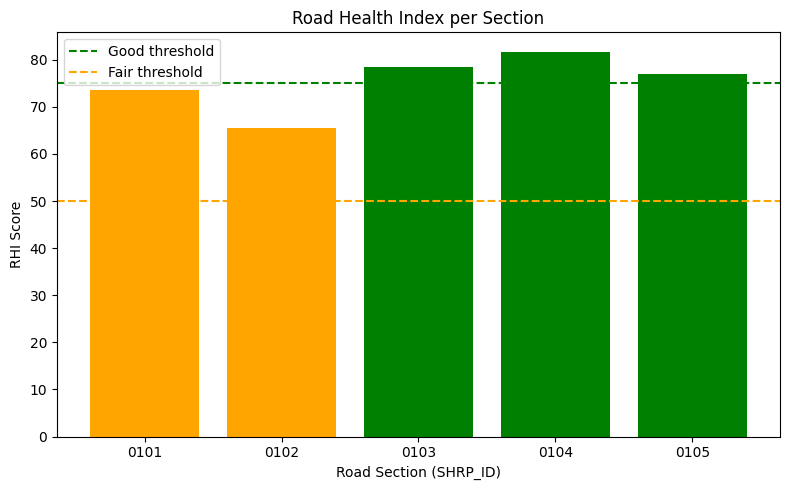

In [6]:
import matplotlib.pyplot as plt

# Save to CSV
rhi_df.to_csv('../outputs/rhi_scores.csv', index=False)
print("Saved!")

# Plot
plt.figure(figsize=(8,5))
colors = rhi_df['ROAD_CONDITION'].map({'Good':'green','Fair':'orange','Poor':'red'})
plt.bar(rhi_df['SHRP_ID'], rhi_df['RHI'], color=colors)
plt.axhline(75, color='green', linestyle='--', label='Good threshold')
plt.axhline(50, color='orange', linestyle='--', label='Fair threshold')
plt.xlabel("Road Section (SHRP_ID)")
plt.ylabel("RHI Score")
plt.title("Road Health Index per Section")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/rhi_scores.png', dpi=150)
plt.show()

In [7]:
import warnings

warnings.filterwarnings('ignore')

print('=== ROAD HEALTH INDEX PREDICTOR ===\n')

# IRI and traffic inputs
mri = float(input('Current IRI/MRI (e.g. 0.85): '))
aadtt = float(input('Daily Truck Count AADTT (e.g. 950): '))
annual_truck_vol = float(input('Annual Truck Volume (e.g. 346750): '))
annual_esal = float(input('Annual ESAL (e.g. 310000): '))
cumulative_esal = float(input('Cumulative ESAL (e.g. 1500000): '))
iri_growth_rate = float(input('IRI Growth Rate (e.g. 0.012): '))
year = float(input('Current Year (e.g. 2025): '))

# FWD inputs
deflections = [float(input(f'PEAK_DEFL_{index} (e.g. {value}): '))
               for index, value in enumerate([450, 280, 210, 180, 140, 110, 70], start=1)]
drop_load = float(input('DROP_LOAD (e.g. 710): '))
drop_height = float(input('DROP_HEIGHT (e.g. 4): '))
pav_family = input('PAVEMENT_FAMILY: ')
lane_no = input('LANE_NO: ')

iri_input = pd.DataFrame([[mri, aadtt, annual_truck_vol, annual_esal,
                         cumulative_esal, iri_growth_rate, year]], columns=features1)
predicted_iri = float(model1.predict(iri_input)[0])
failure_threshold = 2.5
iri_score = float(np.clip(
    ((failure_threshold - predicted_iri) / failure_threshold) * 100, 0, 100
))

pavement_encoder = LabelEncoder().fit(df2['PAVEMENT_FAMILY'])
lane_encoder = LabelEncoder().fit(df2['LANE_NO'])
fwd_input = pd.DataFrame([[
    *deflections, drop_load, drop_height,
    pavement_encoder.transform([pav_family])[0],
    lane_encoder.transform([lane_no])[0]
]], columns=features2)
health = le_target.inverse_transform(model2.predict(fwd_input).astype(int))[0]
fwd_score = {'Good': 100, 'Fair': 60, 'Poor': 20}[health]

rhi = (iri_score + fwd_score) / 2
condition = 'Good' if rhi >= 75 else 'Fair' if rhi >= 50 else 'Poor'

print('\n========== RESULTS ==========')
print(f'Predicted Future IRI  : {predicted_iri:.4f} m/km')
print(f'IRI Score             : {iri_score:.2f} / 100')
print(f'FWD Health            : {health}')
print(f'FWD Score             : {fwd_score} / 100')
print(f'RHI Score             : {rhi:.2f} / 100')
print(f'Road Condition        : {condition}')
print('==============================')

=== ROAD HEALTH INDEX PREDICTOR ===



ValueError: could not convert string to float: ''